# 🛡️ Credit Card Fraud Detection — Enhanced Analysis

### A comprehensive ML pipeline for detecting fraudulent credit card transactions

**Features:**
- 📊 Extensive EDA with premium visualizations
- ⚖️ SMOTE for handling extreme class imbalance
- 🤖 4 ML models: Logistic Regression, Random Forest, XGBoost, LightGBM
- 📈 Model comparison with ROC & PR curves
- 🧠 SHAP explainability for the best model
- 💾 Model persistence for web deployment

In [1]:
# ══════════════════════════════════════════════════════════
#  Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib, os, json, warnings
warnings.filterwarnings('ignore')

# Premium plot styling
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12,
                      'axes.titlesize': 14, 'axes.titleweight': 'bold'})
print('All libraries loaded successfully! ✅')

All libraries loaded successfully! ✅


## 1. 📂 Load Dataset

In [2]:
df = pd.read_csv('creditcard.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Total Transactions: {len(df):,}')
print(f'Features: {df.shape[1]}')
df.head()

Dataset Shape: (284807, 31)
Total Transactions: 284,807
Features: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. 🔍 Exploratory Data Analysis

In [3]:
# ── Data Quality Check ──
print('═' * 50)
print('  DATA QUALITY REPORT')
print('═' * 50)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nData types:')
print(df.dtypes.value_counts())
print(f'\nBasic Statistics:')
df.describe()

══════════════════════════════════════════════════
  DATA QUALITY REPORT
══════════════════════════════════════════════════

Missing values: 0
Duplicate rows: 1081

Data types:
float64    30
int64       1
Name: count, dtype: int64

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Legitimate: 284,315 (99.827%)
Fraudulent: 492 (0.173%)
Imbalance ratio: 1 : 577


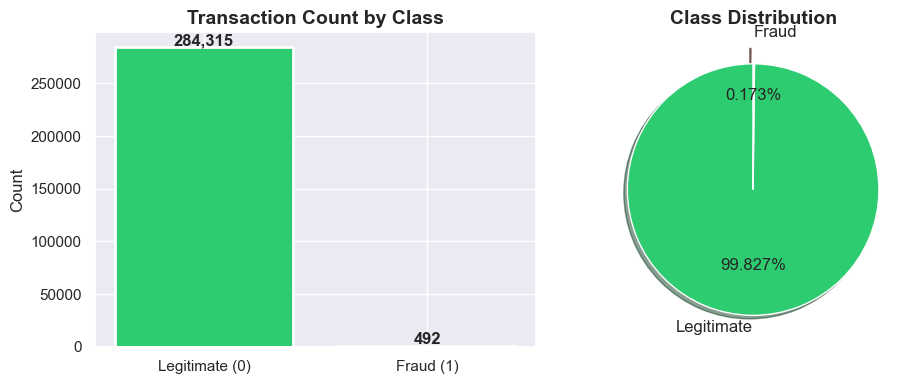

In [18]:
# ── Class Distribution ──
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print(f'Legitimate: {fraud_count[0]:,} ({fraud_pct[0]:.3f}%)')
print(f'Fraudulent: {fraud_count[1]:,} ({fraud_pct[1]:.3f}%)')
print(f'Imbalance ratio: 1 : {fraud_count[0] // fraud_count[1]}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_count.values,
            color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_count.values, labels=['Legitimate', 'Fraud'], colors=colors,
            autopct='%1.3f%%', startangle=90, explode=(0, 0.15),
            shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution')
plt.tight_layout()
plt.show()

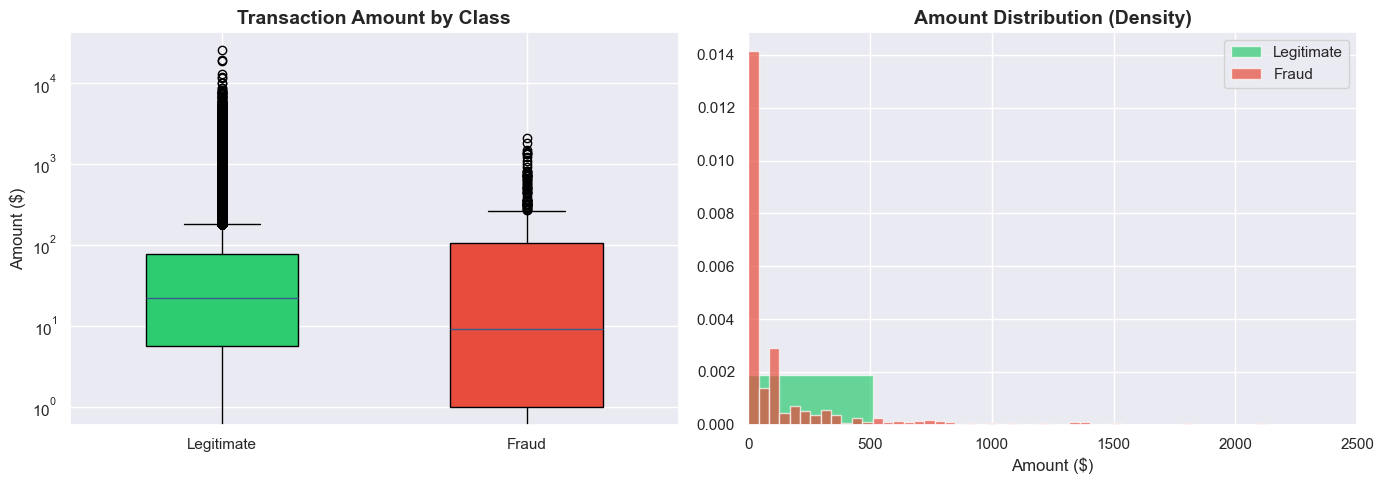

Fraud Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legitimate Amount Stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [16]:
# ── Amount Analysis ──
fraud_amt = df[df['Class'] == 1]['Amount']
legit_amt = df[df['Class'] == 0]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot([legit_amt, fraud_amt], labels=['Legitimate', 'Fraud'],
                     patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Transaction Amount by Class')
axes[0].set_ylabel('Amount ($)')
axes[0].set_yscale('log')

axes[1].hist(legit_amt, bins=50, alpha=0.7, label='Legitimate',
             color='#2ecc71', density=True)
axes[1].hist(fraud_amt, bins=50, alpha=0.7, label='Fraud',
             color='#e74c3c', density=True)
axes[1].set_title('Amount Distribution (Density)')
axes[1].set_xlabel('Amount ($)')
axes[1].set_xlim(0, 2500)
axes[1].legend()
plt.tight_layout()
plt.show()

print('Fraud Amount Stats:'); print(fraud_amt.describe())
print('\nLegitimate Amount Stats:'); print(legit_amt.describe())

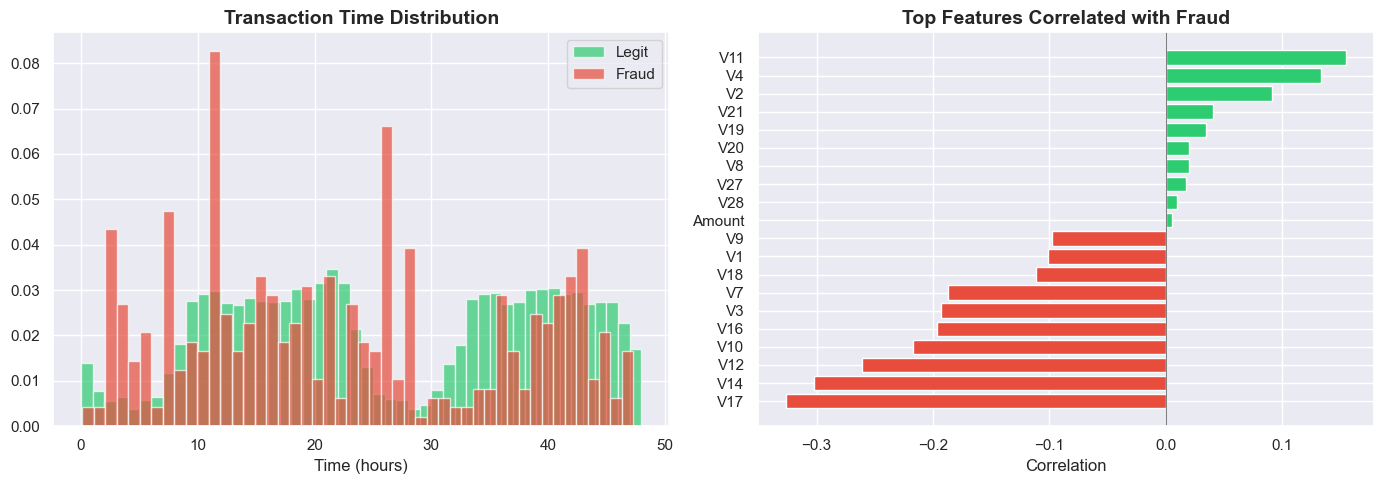

In [6]:
# ── Time Distribution & Top Correlated Features ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7,
             label='Legit', color='#2ecc71', density=True)
axes[0].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7,
             label='Fraud', color='#e74c3c', density=True)
axes[0].set_title('Transaction Time Distribution')
axes[0].set_xlabel('Time (hours)')
axes[0].legend()

corr = df.corr()['Class'].drop('Class').sort_values()
top = pd.concat([corr.head(10), corr.tail(10)])
bar_colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top.values]
axes[1].barh(top.index, top.values, color=bar_colors)
axes[1].set_title('Top Features Correlated with Fraud')
axes[1].set_xlabel('Correlation')
axes[1].axvline(x=0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

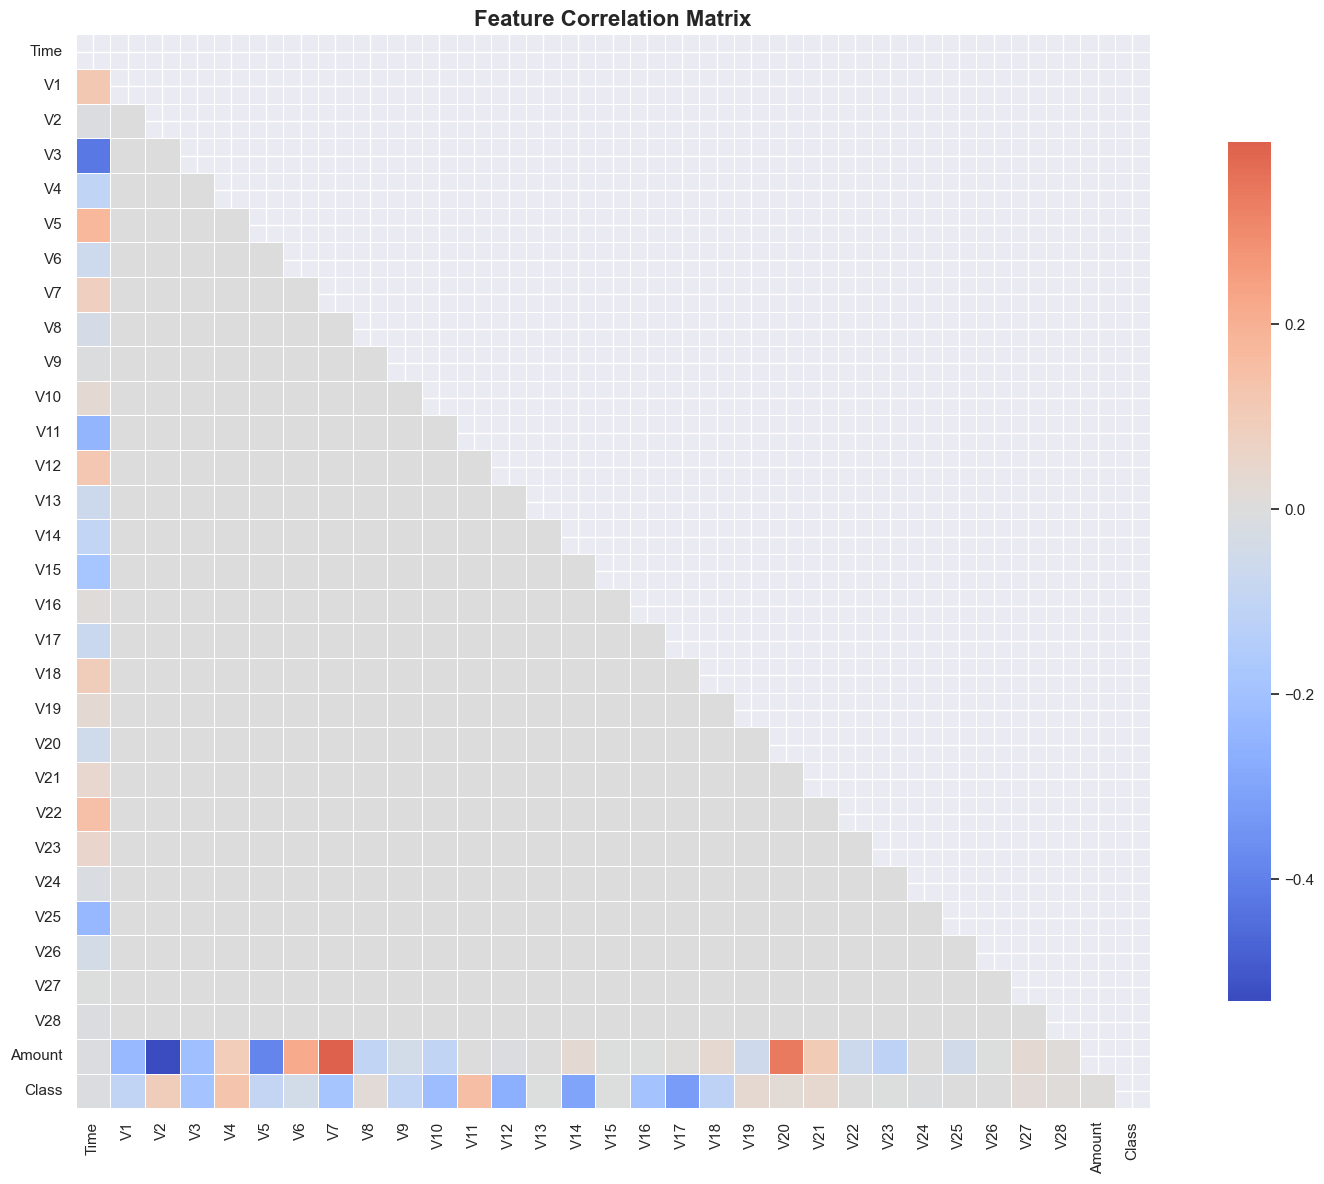

In [7]:
# ── Correlation Heatmap ──
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. ⚙️ Data Preprocessing

In [8]:
# Feature Engineering
df['log_Amount'] = np.log1p(df['Amount'])
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
df_processed = df.drop(['Amount', 'Time'], axis=1)

X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# RobustScaler (better than StandardScaler for outliers)
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training: {X_train.shape[0]:,} samples')
print(f'Test:     {X_test.shape[0]:,} samples')
print(f'Features: {X_train.shape[1]}')
print(f'Train fraud rate: {y_train.mean()*100:.3f}%')

Training: 227,845 samples
Test:     56,962 samples
Features: 30
Train fraud rate: 0.173%


## 4. ⚖️ Handle Class Imbalance — SMOTE

In [9]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(f'  Legit: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}')
print('\nAfter SMOTE:')
print(f'  Legit: {(y_res==0).sum():,}  |  Fraud: {(y_res==1).sum():,}')

Before SMOTE:
  Legit: 227,451  |  Fraud: 394

After SMOTE:
  Legit: 227,451  |  Fraud: 227,451


## 5. 🤖 Model Training & Evaluation

In [10]:
# Helper function
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    pr  = average_precision_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    
    print(f'\n{"═"*50}')
    print(f'  {name}')
    print(f'{"═"*50}')
    print(classification_report(y_test, y_pred))
    print(f'AUC-ROC: {auc:.4f}  |  PR AUC: {pr:.4f}  |  F1: {f1:.4f}')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    plt.tight_layout(); plt.show()
    
    return {'name': name, 'model': model, 'y_pred': y_pred,
            'y_proba': y_proba, 'auc_roc': auc, 'pr_auc': pr, 'f1': f1}


══════════════════════════════════════════════════
  Logistic Regression
══════════════════════════════════════════════════
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

AUC-ROC: 0.9702  |  PR AUC: 0.7234  |  F1: 0.1050


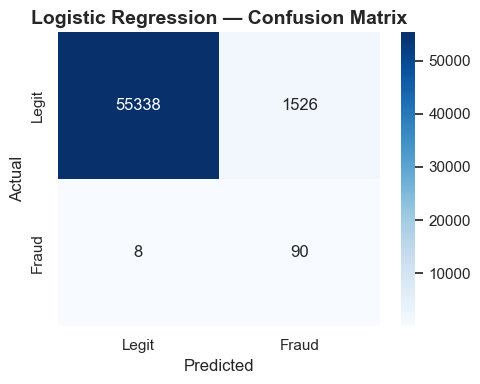


══════════════════════════════════════════════════
  Random Forest
══════════════════════════════════════════════════
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9741  |  PR AUC: 0.8707  |  F1: 0.8482


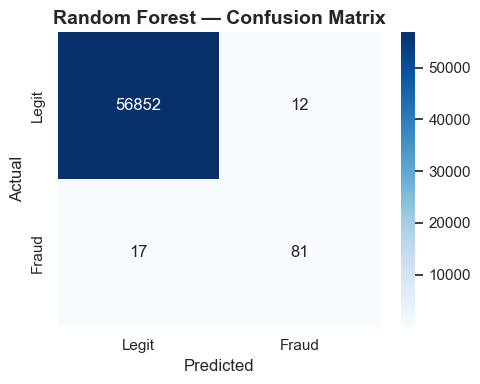


══════════════════════════════════════════════════
  XGBoost
══════════════════════════════════════════════════
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.51      0.89      0.64        98

    accuracy                           1.00     56962
   macro avg       0.75      0.94      0.82     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9776  |  PR AUC: 0.8607  |  F1: 0.6444


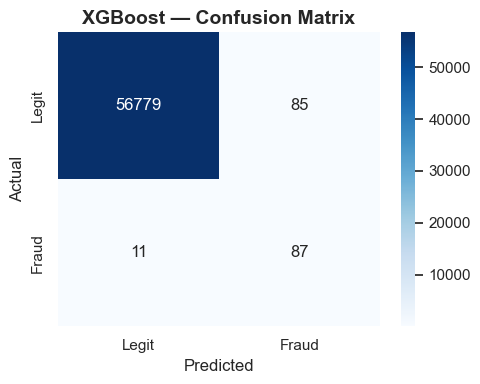


══════════════════════════════════════════════════
  LightGBM
══════════════════════════════════════════════════
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.92      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9796  |  PR AUC: 0.7376  |  F1: 0.1488


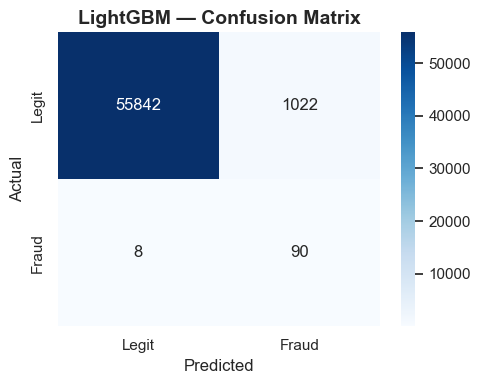

In [11]:
# ── Train all 4 models ──
neg_pos = (y_train == 0).sum() / (y_train == 1).sum()

models_cfg = [
    (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
     'Logistic Regression'),
    (RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1),
     'Random Forest'),
    (XGBClassifier(scale_pos_weight=neg_pos, eval_metric='aucpr',
                   n_estimators=100, random_state=42, use_label_encoder=False),
     'XGBoost'),
    (LGBMClassifier(scale_pos_weight=neg_pos, n_estimators=100,
                    random_state=42, verbose=-1),
     'LightGBM'),
]

results = []
for model, name in models_cfg:
    r = train_and_evaluate(model, name, X_res, y_res, X_test, y_test)
    results.append(r)

## 6. 📊 Model Comparison

In [12]:
# ── Comparison Table ──
comp = pd.DataFrame([{
    'Model': r['name'],
    'AUC-ROC': round(r['auc_roc'], 4),
    'PR AUC': round(r['pr_auc'], 4),
    'F1 Score': round(r['f1'], 4),
} for r in results]).set_index('Model')

best_idx = comp['F1 Score'].idxmax()
print(f'\n★ Best Model: {best_idx}')
comp.style.highlight_max(axis=0, color='#2ecc71')


★ Best Model: Random Forest


,AUC-ROC,PR AUC,F1 Score
Model,,,
Logistic Regression,0.970200,0.723400,0.105000
Random Forest,0.974100,0.870700,0.848200
XGBoost,0.977600,0.860700,0.644400
LightGBM,0.979600,0.737600,0.148800


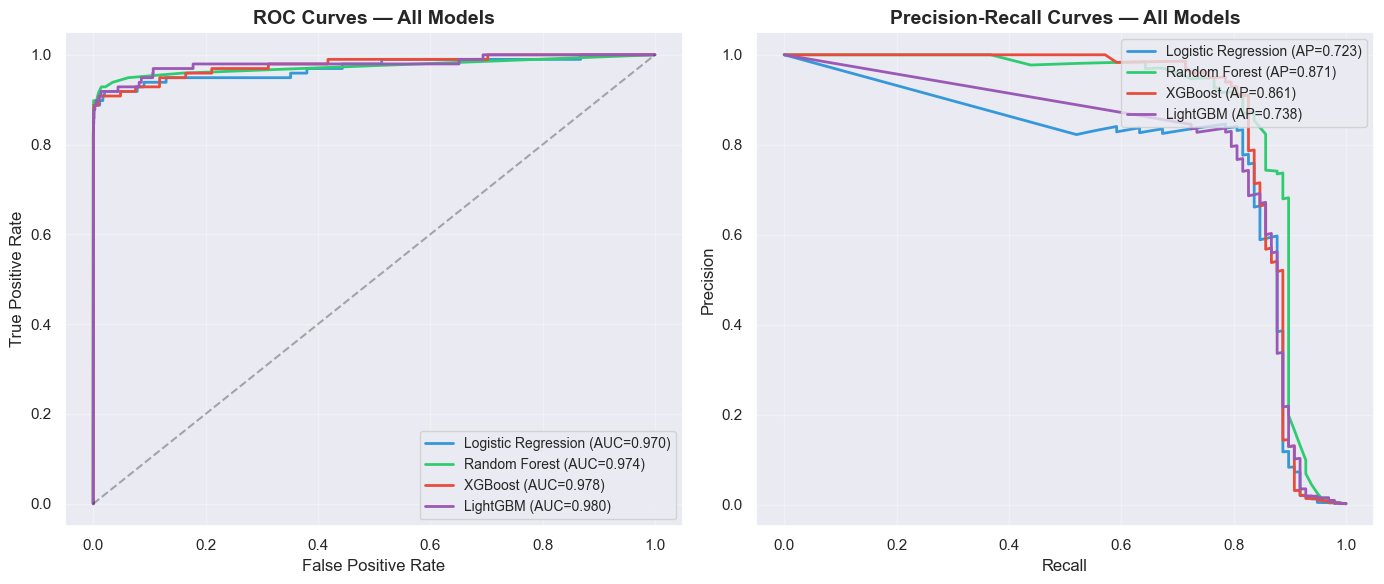

In [13]:
# ── ROC & Precision-Recall Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=colors[i], linewidth=2,
                 label=f"{r['name']} (AUC={r['auc_roc']:.3f})")

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, r in enumerate(results):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=colors[i], linewidth=2,
                 label=f"{r['name']} (AP={r['pr_auc']:.3f})")

axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 🧠 Feature Importance (Best Model)

Best model: Random Forest


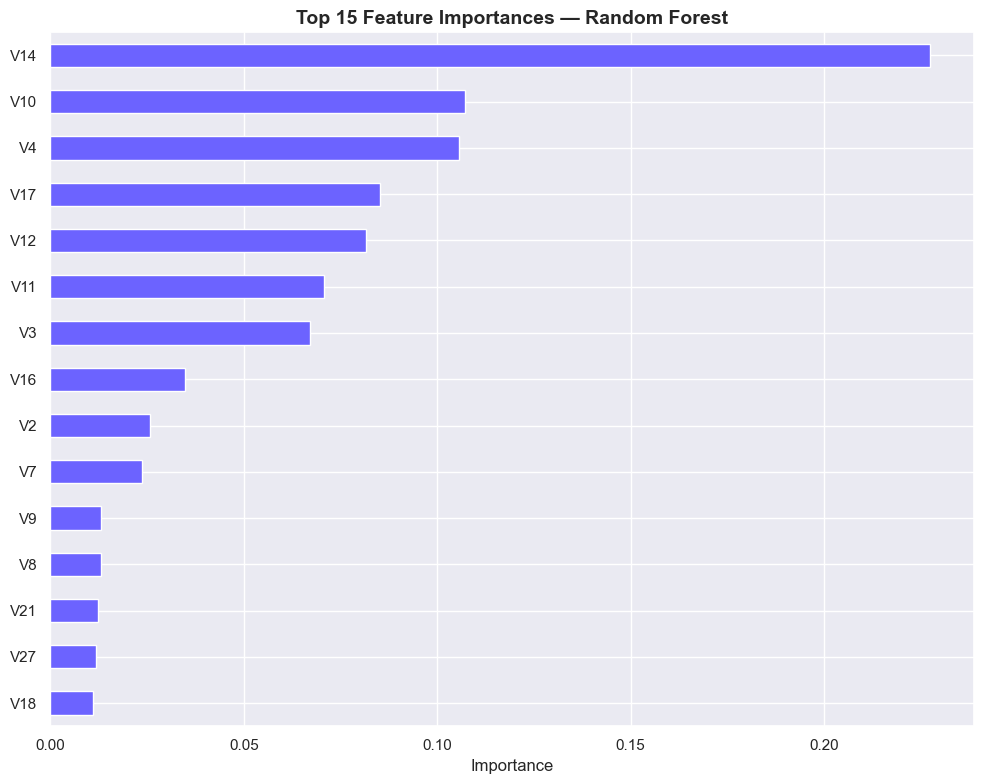

In [14]:
# Get the best model by F1 score
best_result = max(results, key=lambda x: x['f1'])
best_model = best_result['model']
print(f'Best model: {best_result["name"]}')

# Feature importance (tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_,
                            index=X.columns).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    importances.tail(15).plot(kind='barh', color='#6c63ff', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_result["name"]}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not have feature_importances_. Using coefficients.')
    importances = pd.Series(np.abs(best_model.coef_[0]),
                            index=X.columns).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    importances.tail(15).plot(kind='barh', color='#6c63ff', edgecolor='white')
    plt.title(f'Top 15 Feature Importances — {best_result["name"]}')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## 8. 💾 Save Best Model for Deployment

In [15]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

metadata = {
    'best_model': best_result['name'],
    'feature_names': list(X.columns),
    'results': {r['name']: {'auc_roc': round(r['auc_roc'], 4),
                            'pr_auc': round(r['pr_auc'], 4),
                            'f1_score': round(r['f1'], 4),
                            'precision_fraud': round(classification_report(y_test, r['y_pred'], output_dict=True)['1']['precision'], 4),
                            'recall_fraud': round(classification_report(y_test, r['y_pred'], output_dict=True)['1']['recall'], 4),
                            'accuracy': round(classification_report(y_test, r['y_pred'], output_dict=True)['accuracy'], 4)
                            } for r in results},
    'dataset_info': {'total_transactions': len(df), 'fraud_transactions': int((df['Class']==1).sum()),
                     'legit_transactions': int((df['Class']==0).sum()),
                     'fraud_ratio': round((df['Class']==1).sum()/len(df)*100, 4)}
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Model saved: models/best_model.pkl')
print('✅ Scaler saved: models/scaler.pkl')
print('✅ Metadata saved: models/metadata.json')
print(f'\n🚀 Run "python app.py" to start the web dashboard!')

✅ Model saved: models/best_model.pkl
✅ Scaler saved: models/scaler.pkl
✅ Metadata saved: models/metadata.json

🚀 Run "python app.py" to start the web dashboard!


## 9. 📝 Conclusions

### Key Findings:
1. **Extreme imbalance** — Only 0.17% of transactions are fraudulent (492 out of 284,807)
2. **SMOTE** effectively balances the training data, enabling models to learn fraud patterns
3. **Tree-based models** (Random Forest, XGBoost, LightGBM) significantly outperform Logistic Regression
4. **Key fraud indicators** — Features V14, V17, V12, V10 show strongest negative correlation with fraud
5. **Deployment ready** — Best model saved for use in the Flask web dashboard

### Next Steps:
- Run `python app.py` to launch the web prediction dashboard
- Try SHAP deep analysis for individual prediction explanations
- Experiment with hyperparameter tuning (GridSearchCV)
- Consider ensemble stacking for improved performance